# Task-1

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
rng = np.random.default_rng(42)
sales = rng.integers(50, 500, size=(4, 30, 3))

In [4]:
# per shope
per_shop = sales.sum(axis=(1, 2))
print(per_shop, per_shop.shape)

[25751 24730 24062 24356] (4,)


In [5]:
# avg daily sales
avg_daily_cat = sales.sum(axis=(0, 1))
print(avg_daily_cat, avg_daily_cat.shape)

[32955 33332 32612] (3,)


In [6]:
# best day for every shop
daily_totals = sales.sum(axis=2)
best_day = daily_totals.argmax(axis=1)
print(best_day, best_day.shape)

[15 23  7 25] (4,)


In [7]:
# most consistent day
shop_std = daily_totals.std(axis=1)
consistent_shop = shop_std.argmin()

In [8]:
print(shop_std, shop_std.shape)
print(consistent_shop, consistent_shop.shape)

[177.53543934 205.11303117 191.27239448 223.6727868 ] (4,)
0 ()


In [9]:
# category mean
catogory_mean = sales.mean(axis=(0, 1), keepdims=True)
print(catogory_mean, catogory_mean.shape)

[[[274.625      277.76666667 271.76666667]]] (1, 1, 3)


# Task-2

In [ ]:
#Solve a linear system with Ax = b
import timeit

A = np.array([
    [2, 3, -1],
    [4, -1, 2],
    [-1, 2, 3]
])

b = np.array([5, 6, 7])
x = np.linalg.solve(A, b)
print("Answer:", x)
print("Correct:", np.allclose(A @ x, b))

y = np.linalg.inv(A) @ b
print("Inverse answer:", y)
print("Both same:", np.allclose(x, y))

A = np.random.default_rng(42).random((500, 500))
b = np.random.default_rng(42).random(500)

start = timeit.default_timer()
np.linalg.solve(A, b)
solve_time = timeit.default_timer() - start
start = timeit.default_timer()

np.linalg.inv(A) @ b
inverse_time = timeit.default_timer() - start


print("Solve time:", solve_time)
print("Inverse time:", inverse_time)
print("Ratio:", inverse_time / solve_time)

A = np.array([
    [1, 2],
    [2, 4]
])

print("Determinant:", np.linalg.det(A))

try:
    np.linalg.solve(A, [3, 6])
except np.linalg.LinAlgError:
    print("This is a singular matrix")

Answer: [1.04761905 1.52380952 1.66666667]
Correct: True
Inverse answer: [1.04761905 1.52380952 1.66666667]
Both same: True
Solve time: 0.08280069997999817
Inverse time: 0.01566330000059679
Ratio: 0.1891686906557615
Determinant: 0.0
This is a singular matrix


# Task-3

In [ ]:
#Cosine similarity from scratch
def cosine_similarity(a, b):
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))

a = np.array([1, 2])
b = np.array([1, 2])

result = cosine_similarity(a, b)
print("Same:", result)
print(np.isclose(result, 1))

a = np.array([1, 2])
b = np.array([-1, -2])
result = cosine_similarity(a, b)
print("Opposite:", result)
print(np.isclose(result, -1))

a = np.array([1, 0])
b = np.array([0, 1])
result = cosine_similarity(a, b)
print("Perpendicular:", result)
print(np.isclose(result, 0))

rng = np.random.default_rng(42)
vectors = rng.random((100, 50))
query = rng.random(50)

norm_vectors = np.linalg.norm(
    vectors,
    axis=1,
    keepdims=True
)
norm_query = np.linalg.norm(query)

vectors = vectors / norm_vectors
query = query / norm_query
similarities = vectors @ query
print("Similarities:")
print(similarities)
print("Shape:", similarities.shape)

similarity_matrix = vectors @ vectors.T
print("Matrix shape:", similarity_matrix.shape)

Same: 0.9999999999999998
True
Opposite: -0.9999999999999998
True
Perpendicular: 0.0
True
Similarities:
[0.78589114 0.72285879 0.72652111 0.73373766 0.74864018 0.68361977
 0.70644381 0.73240301 0.71527334 0.77756909 0.74208174 0.74086415
 0.79015723 0.78672891 0.71502306 0.7507983  0.79892597 0.77844293
 0.70403163 0.65402539 0.80977418 0.79895899 0.75707563 0.69480371
 0.75544661 0.77066285 0.73022028 0.70886621 0.77778985 0.78673405
 0.77380008 0.71002889 0.77198357 0.73798036 0.72514667 0.76962674
 0.79543812 0.7354807  0.76434509 0.71285065 0.73629945 0.71775773
 0.72951692 0.73667331 0.75250586 0.74081973 0.66789236 0.73134036
 0.74578408 0.74785503 0.73832152 0.7402067  0.84787606 0.72361004
 0.70376292 0.80399709 0.72290534 0.65302391 0.7151937  0.66250324
 0.73340526 0.73851363 0.72847612 0.72425868 0.72916102 0.76682014
 0.67665089 0.73211196 0.71260873 0.78071575 0.73698484 0.78392747
 0.82302426 0.73621467 0.78795804 0.81140053 0.80910844 0.72965455
 0.7725192  0.74587631 0.6

# Task-4

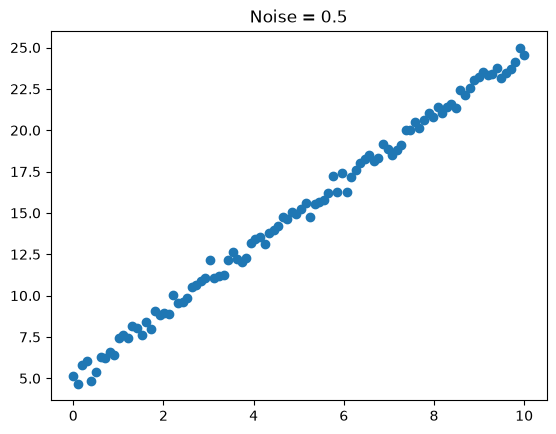

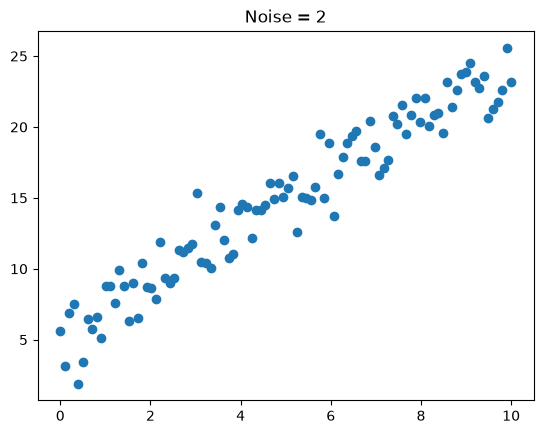

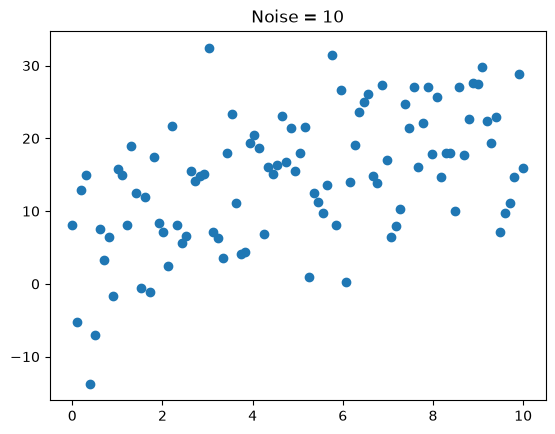

Slope with noise 0.5: 1.9790235816481379
Slope with noise 2: 1.9160943265925512
Slope with noise 10: 1.5804716329627566


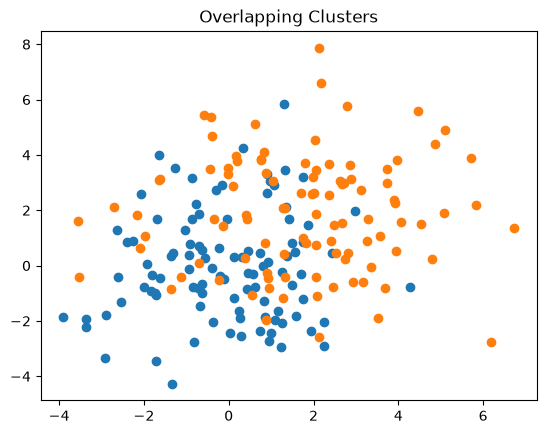

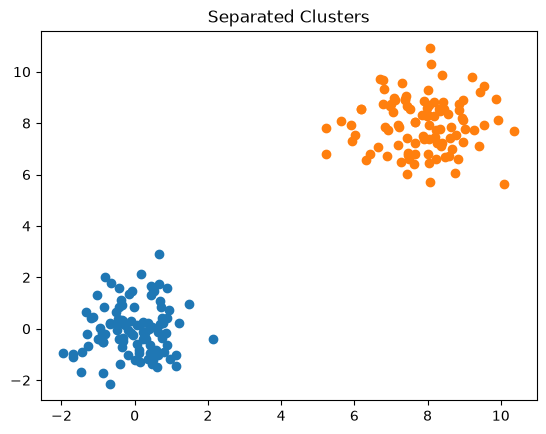

In [ ]:
#Generate synthetic 2D data with controllable noise
def make_line(n, slope, intercept, noise):
    rng = np.random.default_rng(42)
    x = np.linspace(0, 10, n)
    y = slope * x + intercept + rng.normal(0, noise, n)
    return x, y

x, y = make_line(100, 2, 5, 0.5)
plt.scatter(x, y)
plt.title("Noise = 0.5")
plt.show()

x, y = make_line(100, 2, 5, 2)
plt.scatter(x, y)
plt.title("Noise = 2")
plt.show()

x, y = make_line(100, 2, 5, 10)
plt.scatter(x, y)
plt.title("Noise = 10")
plt.show()

x, y = make_line(100, 2, 5, 0.5)
result = np.polyfit(x, y, 1)
print("Slope with noise 0.5:", result[0])

x, y = make_line(100, 2, 5, 2)
result = np.polyfit(x, y, 1)
print("Slope with noise 2:", result[0])

x, y = make_line(100, 2, 5, 10)
result = np.polyfit(x, y, 1)
print("Slope with noise 10:", result[0])

def make_clusters(n, centre, spread, seed):
    rng = np.random.default_rng(seed)
    x = rng.normal(centre[0], spread, n)
    y = rng.normal(centre[1], spread, n)
    return x, y

x1, y1 = make_clusters(100, [0, 0], 2, 42)
x2, y2 = make_clusters(100, [2, 2], 2, 43)

plt.scatter(x1, y1)
plt.scatter(x2, y2)

plt.title("Overlapping Clusters")
plt.show()

x1, y1 = make_clusters(100, [0, 0], 1, 42)
x2, y2 = make_clusters(100, [8, 8], 1, 43)

plt.scatter(x1, y1)
plt.scatter(x2, y2)

plt.title("Separated Clusters")
plt.show()

# Task-5

In [13]:
# 1. Floating point problem
print(0.1 + 0.2)
print(0.1 + 0.2 == 0.3)

# 2. Another example
print(0.4 + 0.8)
print(0.4 + 0.8 == 1.2)


# 3. Integer overflow
x = np.array([100], dtype=np.int8)
print(x + 50)


# 4. Float32 problem
x = np.float32(100000000)
print(x + 1)
print((x + 1) - x)


# 5. Large numbers subtraction
a = np.float32(100000000.1)
b = np.float32(100000000.0)
print(a - b)


# 6. float32 vs float64
n = 1000000
a = np.full(n, 0.1, dtype=np.float32)
b = np.full(n, 0.1, dtype=np.float64)
sum32 = a.sum()
sum64 = b.sum()
print("float32:", sum32)
print("float64:", sum64)
print("Expected:", 100000)


# 7. Machine epsilon
print("float32 epsilon:", np.finfo(np.float32).eps)
print("float64 epsilon:", np.finfo(np.float64).eps)

0.30000000000000004
False
1.2000000000000002
False
[-106]
1e+08
0.0
0.0
float32: 100000.01
float64: 100000.00000000003
Expected: 100000
float32 epsilon: 1.1920929e-07
float64 epsilon: 2.220446049250313e-16
